# Telco Customer Churn: Exploratory Data Analysis & Modeling Insights

Customer churn is a critical problem for subscription and telecom businesses. Acquiring a new customer often costs 5x to 7x more than retaining an existing one. 

In this notebook, we analyze customer churn patterns using the Telco dataset (7,043 customers). The goal is to identify behavioral indicators of churn, investigate price sensitivity, and determine which attributes will serve as strong predictors in our machine learning models.

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.make_dataset import clean_telco_data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

## 1. Data Ingestion & Data Hygiene Check
Let's load the raw data and check for missing values or formatting quirks.

In [2]:
raw_path = Path("../data/raw/telco_customer_churn.csv")
df_raw = pd.read_csv(raw_path)
print(f"Raw dataset dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(3)

Raw dataset dimensions: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### TotalCharges Whitespace Quirk
A known issue in the raw Telco dataset is that `TotalCharges` is read as an object (`str`) instead of a `float`. This happens because new customers with `tenure == 0` have empty whitespace strings `" "` recorded. 

Let's inspect and run our `clean_telco_data` function to coerce them to float (setting zero tenure accounts to 0.0) and map `Churn` to integer 1/0.

In [3]:
blank_charges_count = (df_raw["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"Rows with blank TotalCharges: {blank_charges_count}")

df = clean_telco_data(df_raw)
print(f"Cleaned TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Target distribution:\n{df['Churn'].value_counts(normalize=True).round(3)}")

Rows with blank TotalCharges: 11
Cleaned TotalCharges dtype: float64
Target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


Overall churn rate in the dataset is **26.5%** (1,869 churners out of 7,043 customers). Because of this class imbalance, accuracy can be deceiving — a naive model predicting 'no churn' every time would score 73.5% accuracy while finding zero at-risk customers. We need to evaluate precision, recall, and PR-AUC.

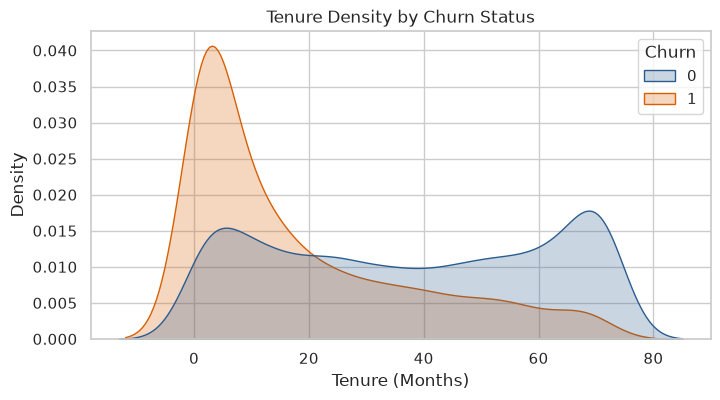

In [4]:
# Tenure distribution by churn
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df, x="tenure", hue="Churn", common_norm=False, fill=True, palette=["#2b5c8f", "#d95f02"], ax=ax)
ax.set_title("Tenure Density by Churn Status")
ax.set_xlabel("Tenure (Months)")
plt.show()

### Observation on Customer Tenure
The tenure distribution shows strong polarization: 
- Churn is heavily concentrated in the first 1–6 months of customer lifetime.
- Customers who survive beyond the first year (12+ months) show much lower hazard rates, stabilizing into loyal long-term subscribers.

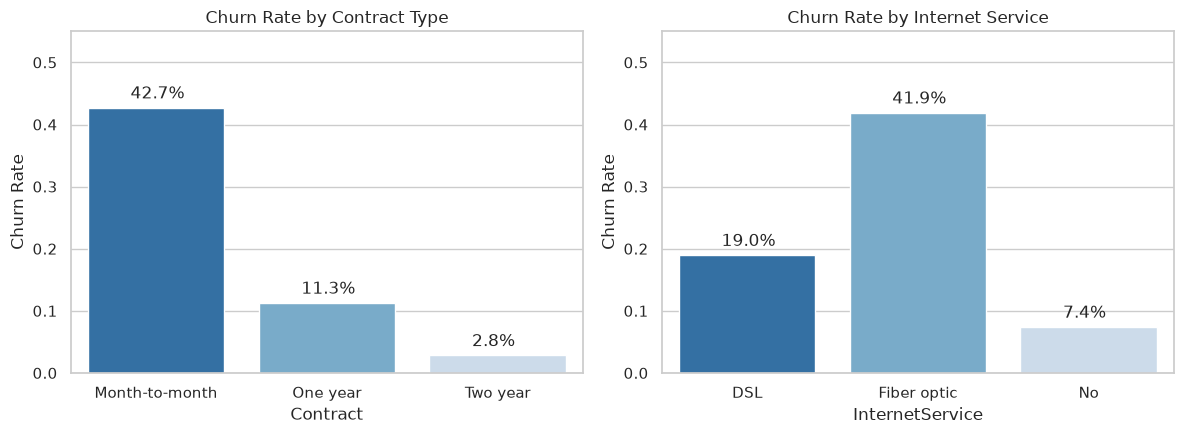

In [5]:
# Contract Type & Internet Service vs Churn Rate
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

contract_churn = df.groupby("Contract")["Churn"].mean().reset_index()
sns.barplot(data=contract_churn, x="Contract", y="Churn", palette="Blues_r", hue="Contract", legend=False, ax=axes[0])
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate")
axes[0].set_ylim(0, 0.55)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + 0.25, p.get_height() + 0.015))

internet_churn = df.groupby("InternetService")["Churn"].mean().reset_index()
sns.barplot(data=internet_churn, x="InternetService", y="Churn", palette="Blues_r", hue="InternetService", legend=False, ax=axes[1])
axes[1].set_title("Churn Rate by Internet Service")
axes[1].set_ylabel("Churn Rate")
axes[1].set_ylim(0, 0.55)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + 0.25, p.get_height() + 0.015))

plt.tight_layout()
plt.show()

### Key Drivers Identified:
1. **Contract Type**: Month-to-month contracts experience a **42.7%** churn rate, compared to 11.3% for 1-year and only 2.8% for 2-year contracts. Commitment length is one of the strongest retention levers.
2. **Fiber Optic Service**: Customers with Fiber Optic churn at **41.9%**, significantly higher than DSL (19.0%) or No Internet (7.4%). Cross-referencing monthly fees shows Fiber customers pay $70–$100+/mo, making them vulnerable to price shock or competing ISP promotions.

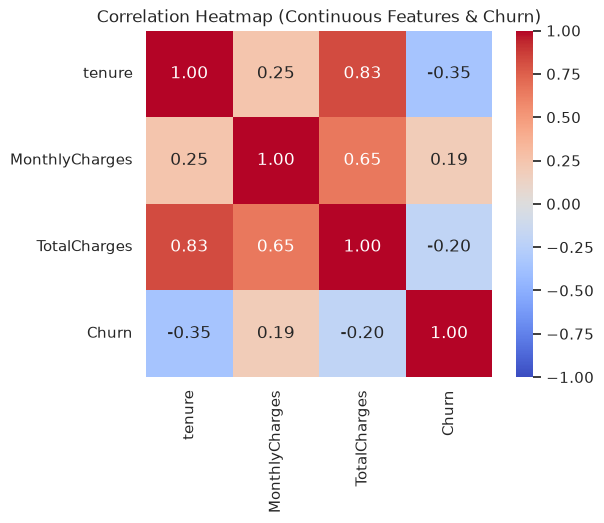

In [6]:
# Correlation between continuous variables
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr = df[num_cols].corr()

plt.figure(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Continuous Features & Churn)")
plt.show()

### Conclusions & Modeling Strategy
- **Feature Preprocessing**: Scale continuous variables (`tenure`, `MonthlyCharges`, `TotalCharges`), one-hot encode categorical features.
- **Leakage Prevention**: All transformations must be fit exclusively on training splits (80%), then applied to testing splits (20%).
- **Modeling Approach**: Establish a simple linear baseline (`LogisticRegression`) to evaluate linear separability, then train a tree-based ensemble (`RandomForestClassifier`) to capture feature interactions.